In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Uber-Jan-Feb-FOIL.csv to Uber-Jan-Feb-FOIL.csv


In [ ]:
df = pd.read_csv("Uber-Jan-Feb-FOIL.csv")  # Adjust filename if needed

In [ ]:
!pip install matplotlib-venn

In [ ]:
!apt-get -qq install -y libfluidsynth1

E: Package 'libfluidsynth1' has no installation candidate


In [ ]:
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive

Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 126209 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.3_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.3) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.3) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.0 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31631 sha256=8a5ce59ef43c9d35e45dfd23374c1b58c1082192f589454fa814bff967fbf170
  Stored in directory: /root/.cache/pip/wheels/32/98/bd/4893d6923dd027f455b250367d402bfd69a6f4416581df46db
Successfully built libarchive


In [ ]:
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 72.1 MB/s eta 0:00:00


In [ ]:
!pip install prophet


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
import statsmodels.api as sm

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:

from sklearn.ensemble import RandomForestRegressor

In [ ]:

import xgboost as xgb

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
# 2. Load Data
df = pd.read_csv("Uber-Jan-Feb-FOIL.csv")
df['date'] = pd.to_datetime(df['date'])
daily_trips = df.groupby('date')['trips'].sum().reset_index()

In [ ]:
df

,dispatching_base_number,date,active_vehicles,trips
0,B02512,2015-01-01,190,1132
1,B02765,2015-01-01,225,1765
2,B02764,2015-01-01,3427,29421
3,B02682,2015-01-01,945,7679
4,B02617,2015-01-01,1228,9537
...,...,...,...,...
349,B02764,2015-02-28,3952,39812
350,B02617,2015-02-28,1372,14022
351,B02682,2015-02-28,1386,14472
352,B02512,2015-02-28,230,1803


In [ ]:
# 3. Feature Engineering
daily_trips['day_of_week'] = daily_trips['date'].dt.dayofweek
daily_trips['is_weekend'] = daily_trips['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
daily_trips['lag_1'] = daily_trips['trips'].shift(1)
daily_trips['lag_2'] = daily_trips['trips'].shift(2)
daily_trips.dropna(inplace=True)

First 5 rows after feature engineering:


,date,trips,day_of_week,is_weekend,lag_1,lag_2
2,2015-01-03,58449,5,1,39189.0,56437.0
3,2015-01-04,40798,6,1,58449.0,39189.0
4,2015-01-05,42752,0,0,40798.0,58449.0
5,2015-01-06,52426,1,0,42752.0,40798.0
6,2015-01-07,62102,2,0,52426.0,42752.0


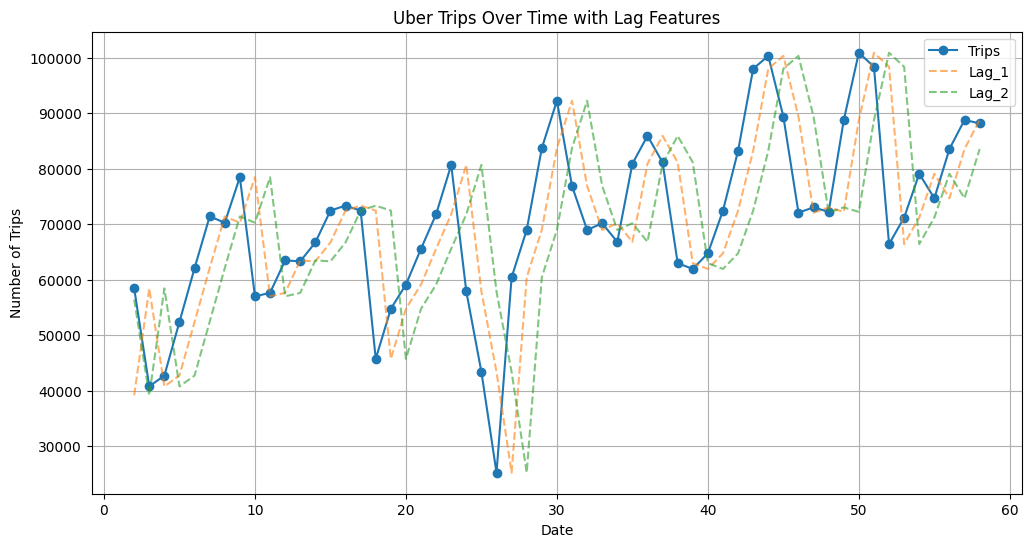

In [ ]:
# View the first few rows
print("First 5 rows after feature engineering:")
display(daily_trips.head())

# Visualizing the new features
plt.figure(figsize=(12, 6))
plt.plot(daily_trips.index, daily_trips['trips'], marker='o', linestyle='-', label='Trips')
plt.plot(daily_trips.index, daily_trips['lag_1'], linestyle='--', alpha=0.6, label='Lag_1')
plt.plot(daily_trips.index, daily_trips['lag_2'], linestyle='--', alpha=0.6, label='Lag_2')
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Uber Trips Over Time with Lag Features")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 4. Train-Test Split
X = daily_trips[['day_of_week', 'is_weekend', 'lag_1', 'lag_2']]
y = daily_trips['trips']

# Splitting into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Training Data Shape: (45, 4)
Testing Data Shape: (12, 4)


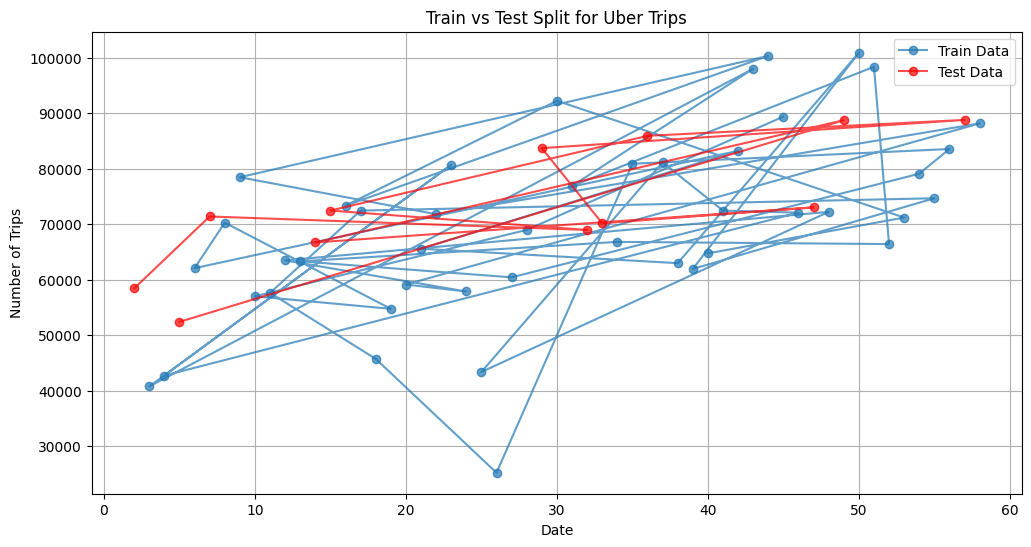

In [ ]:
# View the shapes of the datasets
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Visualizing training vs testing data
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, marker='o', linestyle='-', label="Train Data", alpha=0.7)
plt.plot(y_test.index, y_test, marker='o', linestyle='-', label="Test Data", alpha=0.7, color='red')
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Train vs Test Split for Uber Trips")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 5. Train Machine Learning Models
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    }

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
print("Model Performance Metrics:")
display(results_df)

Model Performance Metrics:


,MAE,RMSE,R2 Score
Linear Regression,4602.315874,6759.721679,0.629437
Random Forest,6543.749167,8321.590533,0.438412
XGBoost,6250.977051,7936.567772,0.489177


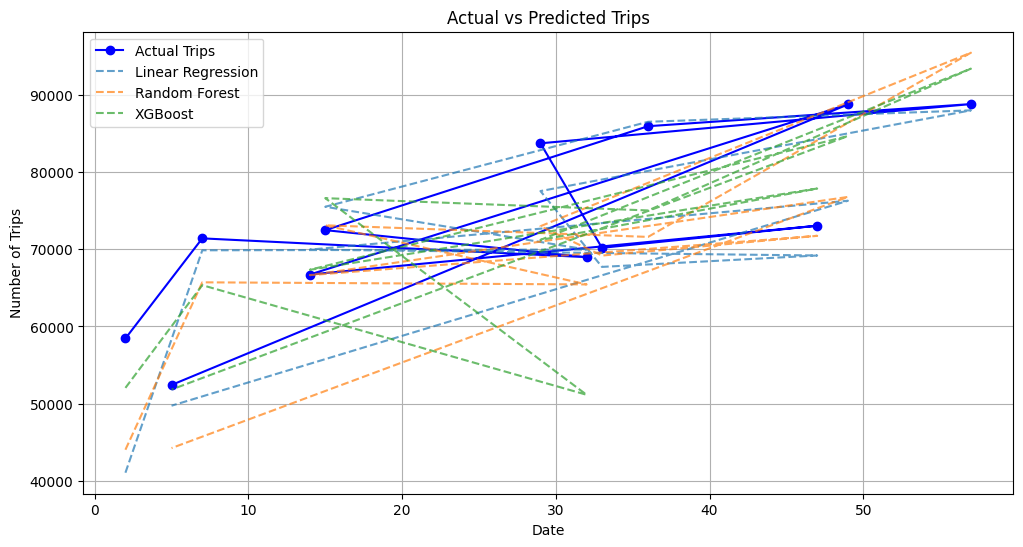

In [ ]:
# Visualization - Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, marker='o', linestyle='-', label="Actual Trips", color='blue')
plt.plot(y_test.index, predictions["Linear Regression"], linestyle='--', label="Linear Regression", alpha=0.7)
plt.plot(y_test.index, predictions["Random Forest"], linestyle='--', label="Random Forest", alpha=0.7)
plt.plot(y_test.index, predictions["XGBoost"], linestyle='--', label="XGBoost", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Actual vs Predicted Trips")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 6. ARIMA Forecasting


# Set date as index
daily_trips.set_index('date', inplace=True)

# Train ARIMA model (SARIMA with seasonal components)
arima_model = SARIMAX(daily_trips['trips'], order=(2,1,2), seasonal_order=(1,1,1,7))
arima_result = arima_model.fit()

# Forecast for the next 30 days
arima_forecast = arima_result.forecast(steps=30)

# View summary of ARIMA model
print("ARIMA Model Summary:")
print(arima_result.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA Model Summary:
                                      SARIMAX Results                                      
Dep. Variable:                               trips   No. Observations:                   57
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood                -523.230
Date:                             Sat, 29 Mar 2025   AIC                           1060.459
Time:                                     02:19:27   BIC                           1073.702
Sample:                                 01-03-2015   HQIC                          1065.483
                                      - 02-28-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3208      1.349     -0.238      0.812      -2.965       2.323
ar.L2 

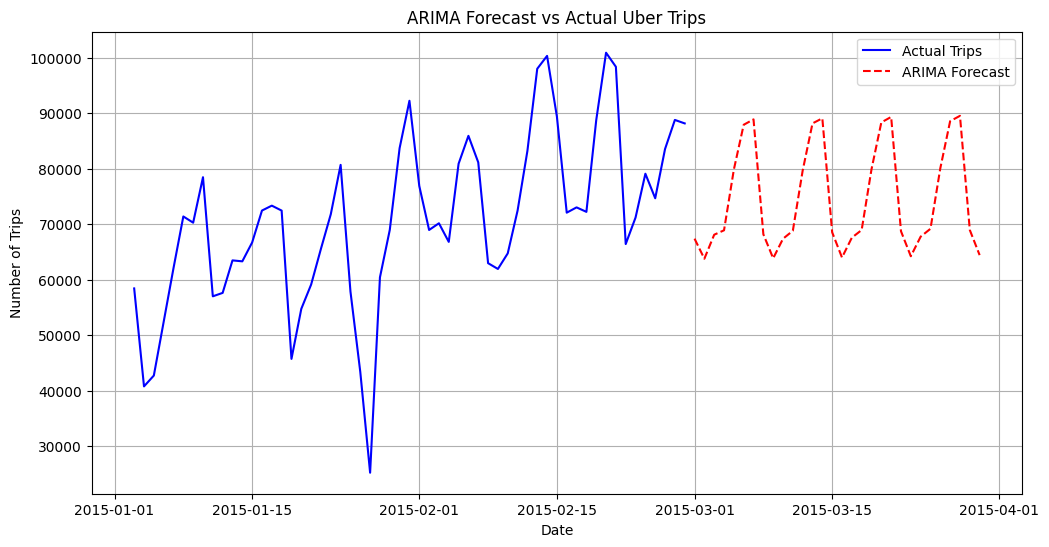

In [ ]:
# Visualizing the ARIMA forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_trips.index, daily_trips['trips'], label="Actual Trips", color='blue')
plt.plot(pd.date_range(start=daily_trips.index[-1], periods=31, freq='D')[1:],
         arima_forecast, linestyle='--', label="ARIMA Forecast", color='red')
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("ARIMA Forecast vs Actual Uber Trips")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 7. Facebook Prophet Forecasting
# Prepare data for Prophet
prophet_df = daily_trips.reset_index()[['date', 'trips']]
prophet_df.columns = ['ds', 'y']  # Prophet requires 'ds' (date) and 'y' (target)

# Initialize and fit Prophet model
prophet_model = Prophet()
prophet_model.fit(prophet_df)

# Create future dataframe for 30-day forecast
future = prophet_model.make_future_dataframe(periods=30)
prophet_forecast = prophet_model.predict(future)

# View Prophet forecast data
print("Prophet Forecast Head:")
display(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfblehpj4/8wy3r7zl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfblehpj4/q97x4aag.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91668', 'data', 'file=/tmp/tmpfblehpj4/8wy3r7zl.json', 'init=/tmp/tmpfblehpj4/q97x4aag.json', 'output', 'file=/tmp/tmpfblehpj4/prophet_model8c9uh6n4/prophet_model-20250329021930.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
02:19:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:19:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet Forecast Head:


,ds,yhat,yhat_lower,yhat_upper
77,2015-03-21,108659.675344,98703.972039,118746.995233
78,2015-03-22,92473.014220,82724.650836,102829.207679
79,2015-03-23,84956.116072,74287.276100,96040.208100
80,2015-03-24,87363.564603,76744.307144,97861.350241
81,2015-03-25,93388.018362,83310.073617,103963.566617
82,2015-03-26,103130.090182,92793.991357,113696.641329
83,2015-03-27,110978.196557,100802.111142,120592.013445
84,2015-03-28,112256.941578,102232.541554,121993.717849
85,2015-03-29,96070.280453,85988.014101,106162.469622
86,2015-03-30,88553.382305,78785.297879,98496.547326


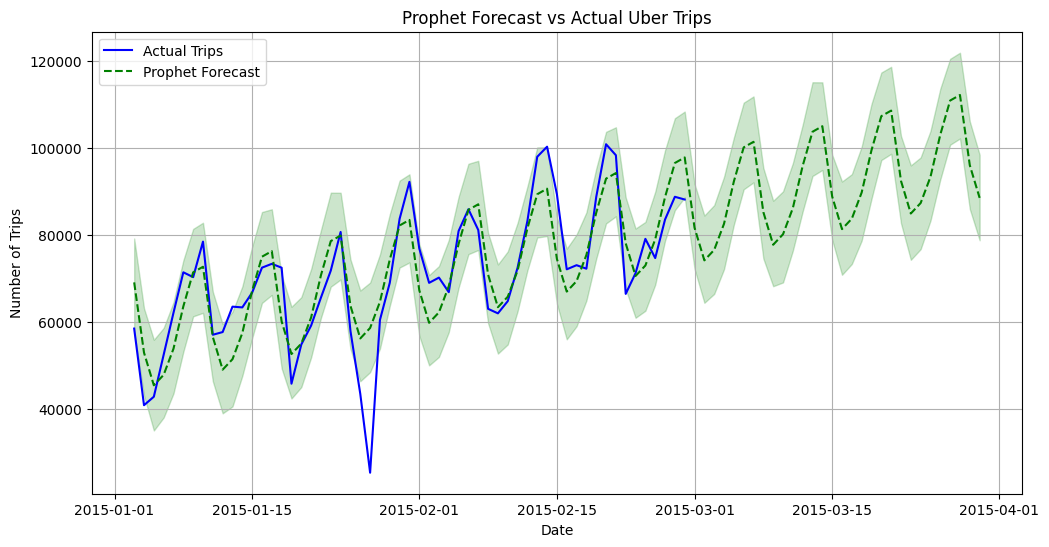

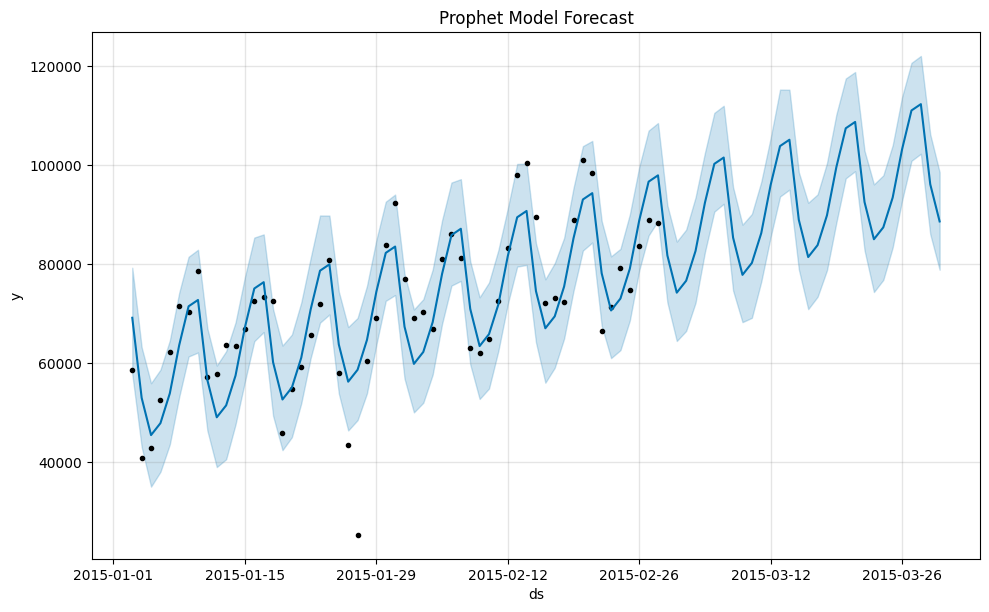

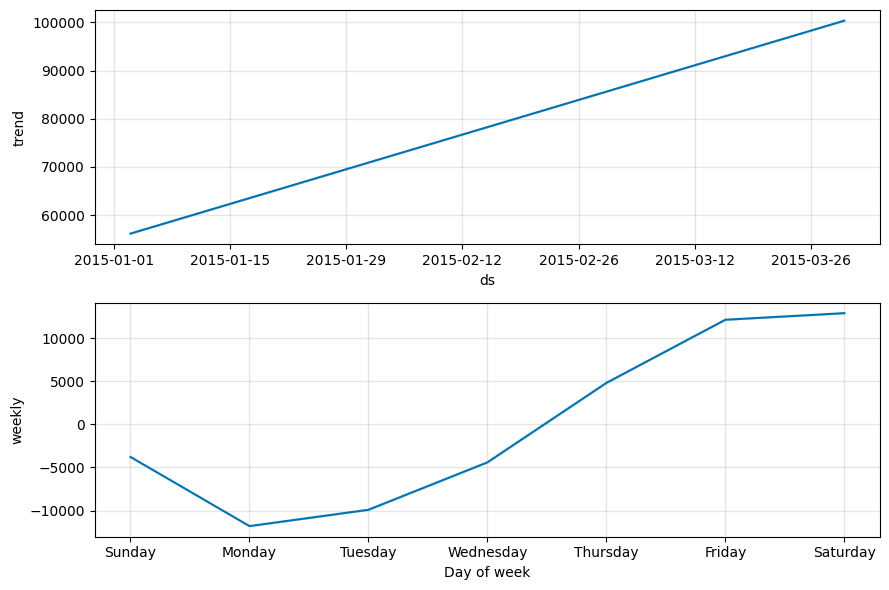

In [ ]:
# Visualization - Prophet Forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_trips.index, daily_trips['trips'], label="Actual Trips", color='blue')
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], linestyle='--', label="Prophet Forecast", color='green')
plt.fill_between(prophet_forecast['ds'], prophet_forecast['yhat_lower'],
                 prophet_forecast['yhat_upper'], color='green', alpha=0.2)
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Prophet Forecast vs Actual Uber Trips")
plt.legend()
plt.grid(True)
plt.show()

# Prophet built-in visualization
prophet_model.plot(prophet_forecast)
plt.title("Prophet Model Forecast")
plt.show()

prophet_model.plot_components(prophet_forecast)
plt.show()

In [ ]:
# 8. Deep Learning - LSTM

from sklearn.preprocessing import MinMaxScaler

# Prepare data for LSTM
lstm_data = daily_trips[['trips']].values
scaler = MinMaxScaler(feature_range=(0,1))
lstm_data = scaler.fit_transform(lstm_data)

# Train-test split (80% training, 20% testing)
train_size = int(len(lstm_data) * 0.8)
train, test = lstm_data[:train_size], lstm_data[train_size:]

# Create sequences for LSTM model
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 5
X_train, y_train = create_sequences(train, seq_length)
X_test, y_test = create_sequences(test, seq_length)

# Reshape data for LSTM (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Define LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM model
history = model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=1)

# Predict using LSTM model
lstm_predictions = model.predict(X_test)

# Reverse scaling to original values
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test = scaler.inverse_transform(y_test)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2072
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0399
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0491
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0438
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0391
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0467
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0614
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0394
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0462
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0419
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0573
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0436
Epoch 13/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0423
Epoch 14/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0288
Epoch 15/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0426
Epoch 16/20
40/40 ━

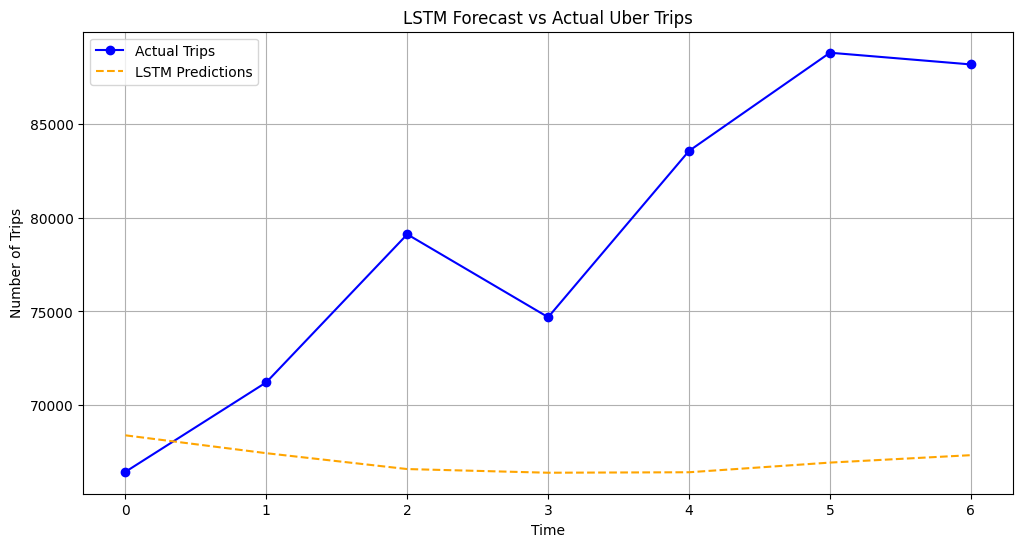

In [ ]:

# Visualization - Actual vs LSTM Predictions
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test, marker='o', linestyle='-', label="Actual Trips", color='blue')
plt.plot(range(len(lstm_predictions)), lstm_predictions, linestyle='--', label="LSTM Predictions", color='orange')
plt.xlabel("Time")
plt.ylabel("Number of Trips")
plt.title("LSTM Forecast vs Actual Uber Trips")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create new time-based features
daily_trips['month'] = daily_trips.index.month
daily_trips['week_of_year'] = daily_trips.index.isocalendar().week
daily_trips['day_of_month'] = daily_trips.index.day
daily_trips['quarter'] = daily_trips.index.quarter
daily_trips['year'] = daily_trips.index.year

# Rolling Statistics for Trend Analysis
daily_trips['rolling_mean_7'] = daily_trips['trips'].rolling(window=7).mean()
daily_trips['rolling_mean_14'] = daily_trips['trips'].rolling(window=14).mean()
daily_trips['rolling_std_7'] = daily_trips['trips'].rolling(window=7).std()

# Fill NaN values created by rolling features
daily_trips.fillna(0, inplace=True)

# View new features
display(daily_trips.tail(10))


,trips,day_of_week,is_weekend,lag_1,lag_2,month,week_of_year,day_of_month,quarter,year,rolling_mean_7,rolling_mean_14,rolling_std_7
date,,,,,,,,,,,,,
2015-02-19,88757,3,0,72243.0,73051.0,2,8,19,1,2015,84845.571429,79031.571429,12317.952804
2015-02-20,100915,4,0,88757.0,72243.0,2,8,20,1,2015,85258.571429,80101.214286,12869.559302
2015-02-21,98380,5,1,100915.0,88757.0,2,8,21,1,2015,84977.857143,81331.428571,12501.821846
2015-02-22,66440,6,1,98380.0,100915.0,2,8,22,1,2015,81697.714286,81577.142857,14062.633060
2015-02-23,71217,0,0,66440.0,98380.0,2,9,23,1,2015,81571.857143,82238.642857,14166.426678
2015-02-24,79115,1,0,71217.0,66440.0,2,9,24,1,2015,82438.142857,83263.571429,13737.441858
2015-02-25,74691,2,0,79115.0,71217.0,2,9,25,1,2015,82787.857143,83422.214286,13463.066991
2015-02-26,83568,3,0,74691.0,79115.0,2,9,26,1,2015,82046.571429,83446.071429,13220.290351
2015-02-27,88806,4,0,83568.0,74691.0,2,9,27,1,2015,80316.714286,82787.642857,10934.516446


In [ ]:
# Reshape 3D array into 2D (Flatten the time-step dimension)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Now train the model
grid_search.fit(X_train_reshaped, y_train)

# Predict
y_pred_rf = grid_search.best_estimator_.predict(X_test_reshaped)

# Evaluate
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

RMSE: 79254.88821076837


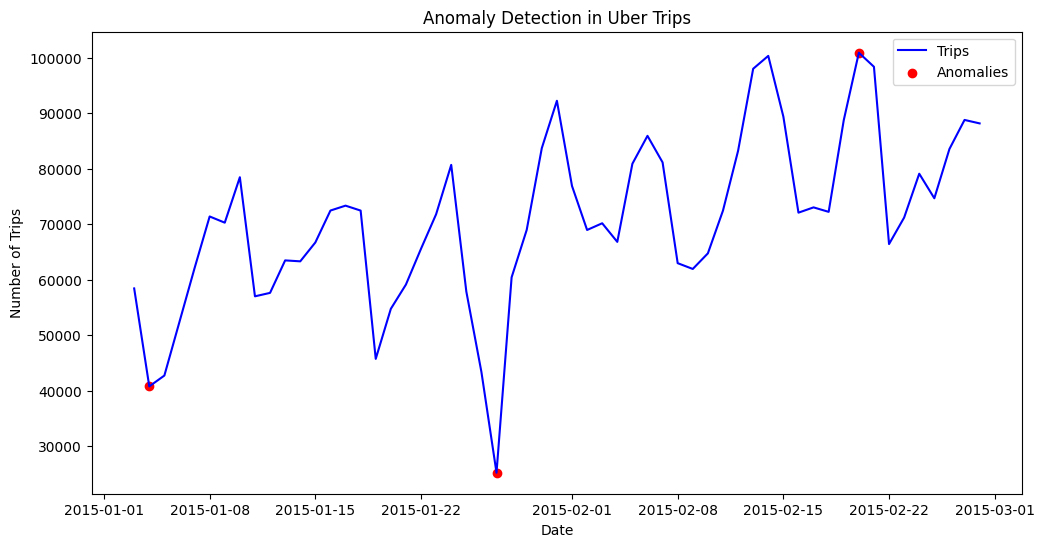

In [ ]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)
daily_trips['anomaly'] = iso_forest.fit_predict(daily_trips[['trips']])

# Identify anomalies
anomalies = daily_trips[daily_trips['anomaly'] == -1]

# Plot anomalies
plt.figure(figsize=(12, 6))
plt.plot(daily_trips.index, daily_trips['trips'], label="Trips", color='blue')
plt.scatter(anomalies.index, anomalies['trips'], color='red', label="Anomalies", marker='o')
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Anomaly Detection in Uber Trips")
plt.legend()
plt.show()


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2079
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0477
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0597
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0513
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0485
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0465
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0811
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0352
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0455
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0421
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0399
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0524
Epoch 13/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0558
Epoch 14/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0821
Epoch 15/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0450
Epoch 16/20
40/40 ━

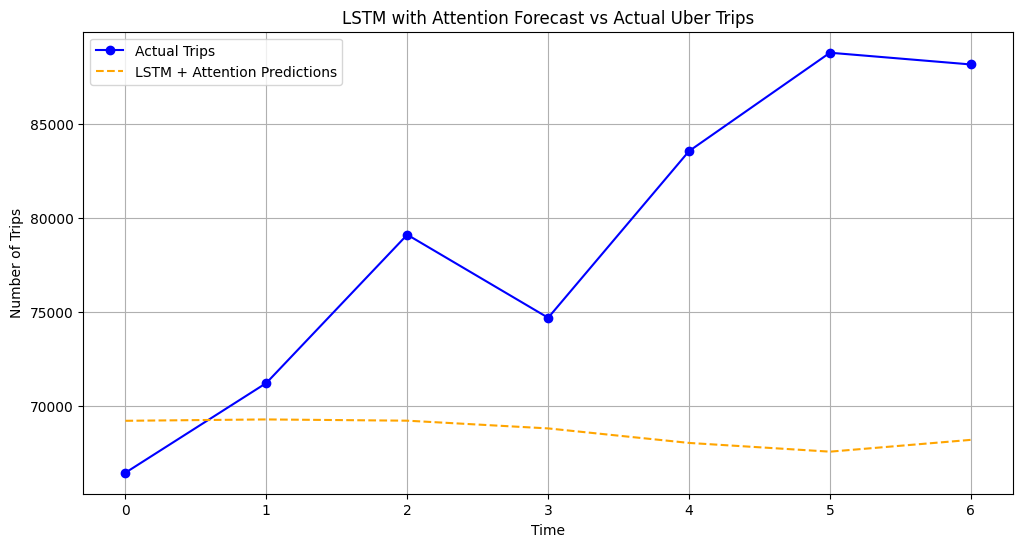

In [ ]:
from tensorflow.keras.layers import Attention

# Define LSTM Model with Attention
input_layer = tf.keras.Input(shape=(seq_length, 1))
lstm_layer = LSTM(50, return_sequences=True)(input_layer)
attention = Attention()([lstm_layer, lstm_layer])
lstm_layer_2 = LSTM(50, return_sequences=False)(attention)
dropout = Dropout(0.2)(lstm_layer_2)
output_layer = Dense(1)(dropout)

# Compile model
lstm_attention_model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
lstm_attention_model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
lstm_attention_model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=1)

# Predict and evaluate
lstm_attention_predictions = lstm_attention_model.predict(X_test)
lstm_attention_predictions = scaler.inverse_transform(lstm_attention_predictions)

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test, marker='o', label="Actual Trips", color='blue')
plt.plot(lstm_attention_predictions, linestyle='--', label="LSTM + Attention Predictions", color='orange')
plt.xlabel("Time")
plt.ylabel("Number of Trips")
plt.title("LSTM with Attention Forecast vs Actual Uber Trips")
plt.legend()
plt.grid(True)
plt.show()
